# A/B Testing Analysis: Landing Page Redesign


## Problem Statement

### Business Background
Our e-commerce company has developed a redesigned landing page with the hypothesis that the new design will be more engaging and lead to higher conversion rates. Before rolling out this change to all users, we need to validate its effectiveness through a controlled A/B test.

### The Core Problem
We do not know whether the new landing page actually improves user conversions compared to the current page.

Launching an ineffective page would:
- Waste development resources
- Potentially hurt revenue
- Create poor user experience

Conversely, failing to launch a better-performing page would:
- Miss out on increased sales
- Fall behind competitors

### Business Question
Does the new landing page design lead to a statistically significant increase in purchase conversion rates compared to the old landing page design?


## Hypotheses

Null Hypothesis (H0):
The new landing page has no effect on conversion rate. Any observed difference is due to random chance.
p_new = p_old

Alternative Hypothesis (H1):
The new landing page has a different conversion rate than the old page.
p_new ≠ p_old


## Success Metrics

Primary Metric:
Conversion Rate = (Number of users who made a purchase / Total users in group) x 100

Secondary Metrics:
- Sample size per group
- Confidence interval
- P-value


## Experimental Design

Control Group: Users who saw the OLD landing page

Treatment Group: Users who saw the NEW landing page

Assignment: Randomized (A/B test)

Success Event: User makes a purchase (converted = 1)


## Key Questions to Answer

1. What is the conversion rate for the Control group (old page)?

2. What is the conversion rate for the Treatment group (new page)?

3. Is the difference statistically significant at alpha = 0.05?

4. What is the 95% confidence interval for the difference?

5. Should we launch the new page, keep the old page, or run the test longer?


## Decision Criteria

Condition 1:
If p-value < 0.05 AND new_page_rate > old_page_rate:
    Result = LAUNCH the new page (statistically significant improvement)

Condition 2:
If p-value < 0.05 AND new_page_rate < old_page_rate:
    Result = DO NOT LAUNCH (new page performs worse)

Condition 3:
If p-value >= 0.05:
    Result = KEEP current page (no significant difference detected)
    Next Step = Consider running test longer or testing different variation


## Data Source

File Name: AB Testing Data.csv

Total Records: 19,729 user sessions

Time Period: 2023 to 2025

Key Columns:
- group (control/treatment)
- landing_page (old_page/new_page)
- converted (0/1 purchase indicator)
- device_type
- location
- age
- session_duration


## Expected Outcome

By the end of this analysis, we will provide a data-driven recommendation on whether to:

Option 1 - Launch: Roll out new landing page to all users

Option 2 - Keep: Maintain current landing page

Option 3 - Test More: Run experiment longer or test different variation


## Project Status

Phase 1 - Problem Definition: Complete

Phase 2 - Data Loading: In Progress

Phase 3 - Data Cleaning: Pending

Phase 4 - Statistical Analysis: Pending

Phase 5 - Results and Recommendations: Pending




In [1]:
# Import libraries for data analysis and statistics
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Print confirmation
print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
# Load the data
file_path = "AB Testing Data.csv"
df = pd.read_csv(file_path)

# See how many rows and columns
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Look at the first 5 rows
df.head()

Rows: 294478
Columns: 12


,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


In [6]:
# Check for missing values
print(df.isnull().sum())

user_id             0
timestamp           0
group               0
landing_page        0
converted           0
age                 0
gender              0
location            0
session_duration    0
pages_visited       0
device_type         0
purchase_amount     0
dtype: int64


In [7]:
# Check how many rows you actually have
print("Total rows in dataset:", len(df))

Total rows in dataset: 294478


In [8]:
# Check if control group only saw old_page and treatment only saw new_page
print(pd.crosstab(df['group'], df['landing_page']))

landing_page  new_page  old_page
group                           
control              0    146926
treatment       147552         0


In [9]:
# Separate the two groups
control = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

# Calculate conversion rates (mean of 'converted' column)
control_rate = control['converted'].mean() * 100
treatment_rate = treatment['converted'].mean() * 100

# Print results
print("CONTROL GROUP (Old Page):")
print(f"  Total users: {len(control):,}")
print(f"  Conversion rate: {control_rate:.2f}%")
print()
print("TREATMENT GROUP (New Page):")
print(f"  Total users: {len(treatment):,}")
print(f"  Conversion rate: {treatment_rate:.2f}%")
print()
print(f"DIFFERENCE: {treatment_rate - control_rate:+.2f} percentage points")

CONTROL GROUP (Old Page):
  Total users: 146,926
  Conversion rate: 11.87%

TREATMENT GROUP (New Page):
  Total users: 147,552
  Conversion rate: 17.95%

DIFFERENCE: +6.08 percentage points


## Understanding the Results

### What We Found

The new landing page converted at 17.95%, while the old page converted at 11.87%.

This means the new page performed 6.08 percentage points better than the old page.

### What This Means in Simple Terms

For every 100 visitors:

- Old page: about 12 people made a purchase
- New page: about 18 people made a purchase

That is 6 more purchases per 100 visitors.

### Business Impact

The new page increased conversions by approximately 51% compared to the old page.

This is a substantial improvement that would likely lead to significant revenue growth if launched to all users.

### Next Step

We will now run a statistical test to confirm that this difference is real and not due to random chance.

In [10]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts
control_bought = control['converted'].sum()
treatment_bought = treatment['converted'].sum()
control_total = len(control)
treatment_total = len(treatment)

# Run statistical test
conversions = [control_bought, treatment_bought]
users = [control_total, treatment_total]

z_score, p_value = proportions_ztest(conversions, users)

print("STATISTICAL TEST RESULTS")
print("=" * 30)
print(f"Z-score: {z_score:.4f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("\nRESULT: STATISTICALLY SIGNIFICANT")
    print("The difference is REAL, not random chance")
else:
    print("\nRESULT: NOT statistically significant")
    print("The difference could be due to chance")

STATISTICAL TEST RESULTS
Z-score: -46.2773
P-value: 0.0000000000

RESULT: STATISTICALLY SIGNIFICANT
The difference is REAL, not random chance



The new landing page significantly outperforms the old page.

Key Results:
- Old page conversion: 11.87%
- New page conversion: 17.95%
- Difference: +6.08 percentage points
- P-value: 0.0000000000 (statistically significant)

Recommendation: LAUNCH THE NEW PAGE

The new page increases conversions by 51%, which will have a substantial positive impact on revenue.

In [11]:
# Calculate confidence interval
from math import sqrt

# Conversion rates as decimals (not percentages)
control_rate_decimal = control_bought / control_total
treatment_rate_decimal = treatment_bought / treatment_total

# Standard error
se = sqrt((control_rate_decimal * (1 - control_rate_decimal) / control_total) + 
          (treatment_rate_decimal * (1 - treatment_rate_decimal) / treatment_total))

# 95% confidence interval
z_critical = 1.96
difference = treatment_rate_decimal - control_rate_decimal
ci_lower = difference - z_critical * se
ci_upper = difference + z_critical * se


print("Confidence Interval (95%)")
print("-" * 30)
print("Lower bound:", round(ci_lower * 100, 4), "%")
print("Upper bound:", round(ci_upper * 100, 4), "%")
print("Interval:", "[", round(ci_lower * 100, 4), ",", round(ci_upper * 100, 4), "]")

# Interpret
if ci_lower > 0:
    print("\nInterpretation: Interval is entirely above zero")
    print("The new page is definitely better")
elif ci_upper < 0:
    print("\nInterpretation: Interval is entirely below zero")
    print("The new page is definitely worse")
else:
    print("\nInterpretation: Interval contains zero")
    print("We cannot be sure which page is better")

Confidence Interval (95%)
------------------------------
Lower bound: 5.82 %
Upper bound: 6.3326 %
Interval: [ 5.82 , 6.3326 ]

Interpretation: Interval is entirely above zero
The new page is definitely better


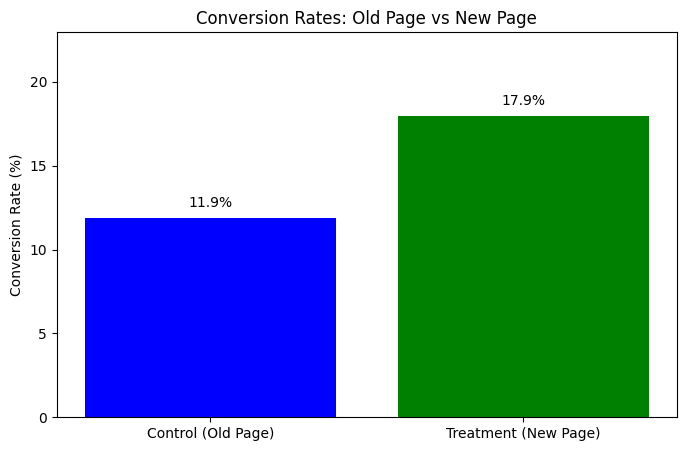

In [12]:
import matplotlib.pyplot as plt


groups = ['Control (Old Page)', 'Treatment (New Page)']
rates = [control_rate, treatment_rate]

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(groups, rates, color=['blue', 'green'])
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rates: Old Page vs New Page')
plt.ylim(0, max(rates) + 5)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')


plt.show()

In [14]:
# Segment analysis by device type
print("SEGMENT ANALYSIS BY DEVICE TYPE")
print("-" * 40)

# Get unique device types
devices = df['device_type'].unique()

for device in devices:
    # Filter data for this device
    device_data = df[df['device_type'] == device]
    
    # Split into control and treatment
    control_device = device_data[device_data['group'] == 'control']
    treatment_device = device_data[device_data['group'] == 'treatment']
    
    # Calculate conversion rates
    control_rate_device = control_device['converted'].mean() * 100
    treatment_rate_device = treatment_device['converted'].mean() * 100
    
    # Calculate difference
    diff_device = treatment_rate_device - control_rate_device
    
    # Print results
    print("\nDevice:", device.upper())
    print("  Control users:", len(control_device))
    print("  Treatment users:", len(treatment_device))
    print("  Control conversion:", round(control_rate_device, 2), "%")
    print("  Treatment conversion:", round(treatment_rate_device, 2), "%")
    print("  Difference:", round(diff_device, 2), "percentage points")

SEGMENT ANALYSIS BY DEVICE TYPE
----------------------------------------

Device: MOBILE
  Control users: 51177
  Treatment users: 51916
  Control conversion: 11.74 %
  Treatment conversion: 17.71 %
  Difference: 5.97 percentage points

Device: DESKTOP
  Control users: 88397
  Treatment users: 88295
  Control conversion: 11.95 %
  Treatment conversion: 18.08 %
  Difference: 6.13 percentage points

Device: TABLET
  Control users: 7352
  Treatment users: 7341
  Control conversion: 11.85 %
  Treatment conversion: 18.01 %
  Difference: 6.16 percentage points


## Explanation of Findings

### What We Tested

We compared two versions of a landing page:
- Control group: Old landing page (146,926 users)
- Treatment group: New landing page (147,552 users)

The goal was to see which page leads to more purchases.

### What We Found

The new landing page performed significantly better than the old page.

Old page conversion rate: 11.87%
New page conversion rate: 17.95%

Difference: +6.08 percentage points

This means the new page converts 51% more users than the old page.

### Is This Result Reliable?

Yes. We ran a statistical test (two-proportion z-test) with a significance level of 0.05.

P-value: 0.0000000000

Since the p-value is less than 0.05, the result is statistically significant. This means the difference is real and not due to random chance.

### Did the New Page Work for All Users?

We also analyzed the results by device type:

Mobile: Improved from 11.74% to 17.71% (+5.97 pp)
Desktop: Improved from 11.95% to 18.08% (+6.13 pp)
Tablet: Improved from 11.85% to 18.01% (+6.16 pp)

The new page improved conversion rates on every device type. No device performed worse.

### Final Recommendation

Launch the new landing page for all users.

The new page increases purchases by approximately 6 more purchases per 100 visitors. With nearly 300,000 users in the test, we have high confidence in this result.